In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../../../../Data/titanic_toy.csv")
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [3]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [4]:
df['Age_imputed'] = df['Age']
df['Fare_imputed'] = df['Fare']

In [5]:
df['Age_imputed'][df['Age_imputed'].isnull()] = df['Age'].dropna().sample(df['Age_imputed'].isnull().sum()).values
df['Fare_imputed'][df['Fare_imputed'].isnull()] = df['Fare'].dropna().sample(df['Fare_imputed'].isnull().sum()).values
df

C:\Users\Jehan\AppData\Local\Temp\ipykernel_13360\2369387511.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df['Age_imputed'][df['Age_imputed'].isnull()] = df['Age'].dropna().sample(df['Age_imputed'].isnull().sum()).values
C:\Users\Jehan\AppData\Local\Temp\ipykernel_13360\2369387511.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, becaus

,Age,Fare,Family,Survived,Age_imputed,Fare_imputed
0,22.0,7.2500,1,0,22.0,7.2500
1,38.0,71.2833,1,1,38.0,71.2833
2,26.0,7.9250,0,1,26.0,7.9250
3,35.0,53.1000,1,1,35.0,53.1000
4,35.0,8.0500,0,0,35.0,8.0500
...,...,...,...,...,...,...
886,27.0,13.0000,0,0,27.0,13.0000
887,19.0,30.0000,0,1,19.0,30.0000
888,NaN,23.4500,3,0,NaN,23.4500
889,26.0,NaN,0,1,26.0,NaN


In [13]:
print(df['Age'].var())
print(df['Age_imputed'].var())
print(df['Fare'].var())
print(df['Fare_imputed'].var())

211.01912474630802
211.01912474630802
2530.6730768999514
2530.6730768999514


In [6]:
df.isnull().sum()

Age             177
Fare             45
Family            0
Survived          0
Age_imputed     177
Fare_imputed     45
dtype: int64

# Check Distribution

<Axes: xlabel='Age', ylabel='Density'>

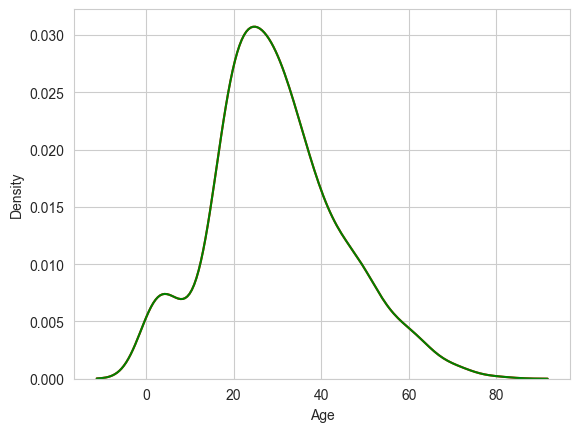

In [8]:
sns.kdeplot(data=df, x='Age',color='red')
sns.kdeplot(data=df, x='Age_imputed',color='green')

<Axes: xlabel='Fare', ylabel='Density'>

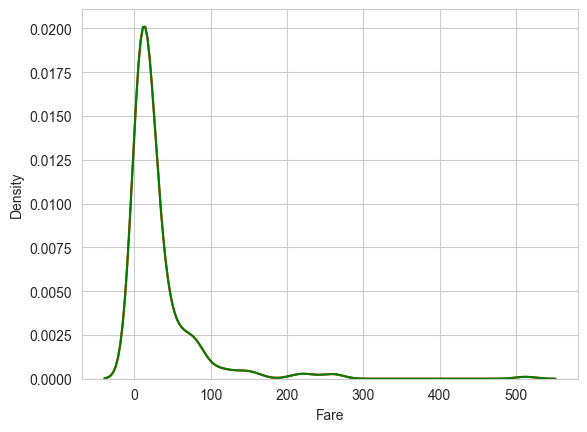

In [9]:
sns.kdeplot(data=df, x='Fare',color='red')
sns.kdeplot(data=df, x='Fare_imputed',color='green')